# Hydrograph examples using our predictive equation

In [27]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Model Functions

τ*c evolution - transport capacity (tc)

In [54]:
def evolve_tauc_tc(
    tau_star,           # array of Shields stress τ*(t)
    dt,                 # timestep between τ* samples (15 minutes in my case)
    tau_c_min,          # minimum τ*c global
    tau_c_max,          # maximum τ*c global
    event_indices,      # time labels or integer positions where τ*c observations are available
    tau_c_obs,          # observed τ*c values at event_indices
    A = 0.2924,
    B = 8.6866,
    multiplicative_factor=1  # factor to adjust k values 
):

    # convert τ* to numeric 1D array and keep index if Series
    if isinstance(tau_star, pd.Series):
        tau_index = tau_star.index
        tau_star_vals = tau_star.to_numpy(dtype=float)
    else:
        tau_index = None
        tau_star_vals = np.asarray(tau_star, dtype=float)

    if tau_star_vals.ndim != 1:
        raise ValueError("tau_star must be 1D after conversion")

    # convert event indices to integer positions in tau_star_vals
    event_labels = np.asarray(event_indices)
    if tau_index is not None:
        event_pos = tau_index.get_indexer(event_labels)

        # allow an initialization observation before forcing starts (e.g., event 0 while tau index starts at 1)
        missing_mask = event_pos < 0
        if np.any(missing_mask) and np.issubdtype(event_labels.dtype, np.number):
            before_start = missing_mask & (event_labels < tau_index.min())
            event_pos[before_start] = 0

        if np.any(event_pos < 0):
            missing_labels = event_labels[event_pos < 0]
            raise ValueError(f"some event indices are not in tau_star index: {missing_labels}")
    else:
        event_pos = np.asarray(event_indices, dtype=int)

    # keep only observed τ*c values that are not NaN
    tau_c_obs_arr = np.asarray(tau_c_obs, dtype=float)
    valid_obs_mask = ~np.isnan(tau_c_obs_arr)
    event_pos_valid = event_pos[valid_obs_mask]
    tau_c_obs_valid = tau_c_obs_arr[valid_obs_mask]

    # initialize modeled τ*c, τ*c_eq, and k array
    n = len(tau_star_vals)
    tau_c = np.full(n, np.nan, dtype=float)  # nan means τ*c is undefined (e.g., during gaps)
    tau_c_pot = np.full(n, np.nan, dtype=float)
    tau_c_conv = np.full(n, np.nan, dtype=float)
    k_array = np.full(n, np.nan, dtype=float)
    tauc_ratio = np.full(n, np.nan, dtype=float)

    tau_c_obs_dict = dict(zip(event_pos_valid, tau_c_obs_valid))
    was_in_gap = True

    i = 0
    while i < n:

        # initialize τ*c when observation exists
        if was_in_gap and i in tau_c_obs_dict:
            tau_c_current = tau_c_obs_dict[i]
            tau_c[i] = tau_c_current
            was_in_gap = False

            # also compute potential τ*c and ratio at initialization timestep
            t = tau_star_vals[i]
            if np.isfinite(t) and np.isfinite(tau_c_current) and tau_c_current > 0:
                ks = 50
                xs = 0.79
                kw = 3.7

                if t / tau_c_current <= 1:
                    tau_conv = tau_c_min + (tau_c_max - tau_c_min) / (1 + np.exp(-ks * (t / tau_c_current - xs)))
                    tau_pot_pure = tau_conv
                else:
                    tau_pot_pure = tau_c_min + (tau_c_max - tau_c_min) * (t / tau_c_current) ** (-kw)

                tau_c_pot[i] = tau_pot_pure
                tauc_ratio[i] = t / tau_c_current
            continue

        # forward evolution with our equation
        if i > 0 and not np.isnan(tau_c[i - 1]):  # if previous τ*c is defined, we can evolve
            tau_c_current = tau_c[i - 1]  # determine previous τ*c
        else:
            # τ* present but τ*c not yet initialized
            i += 1
            continue

        t = tau_star_vals[i]  # current τ*

        if not np.isfinite(t) or not np.isfinite(tau_c_current) or tau_c_current <= 0:
            i += 1
            continue

        # sigmoid parameters from flume data
        ks = 50
        xs = 0.79
        kw = 3.7

        if t / tau_c_current <= 1:  # if τ* is below max τ*c, equilibrium is the max of current τ*c and convergence function
            tau_conv = tau_c_min + (tau_c_max - tau_c_min) / (1 + np.exp(-ks * (t / tau_c_current - xs)))
            tau_pot = max(tau_c_current, tau_conv)  # τ*c cannot decrease below current value if τ* is low
            tau_pot_pure = tau_conv
        else:  # otherwise, equilibrium is given by the weakening function
            tau_conv = tau_c_min + (tau_c_max - tau_c_min) * (t / tau_c_current) ** (-kw)
            tau_pot = tau_conv
            tau_pot_pure = tau_conv

        # calculate k (function of applied tau*)
        k = A * (t / tau_c_max) ** B

        # new tau_c evolution equation
        tau_c_conv[i] = tau_pot # note: the actual value tauc will converge to (with the conditionals)
        k_array[i] = k
        tau_c_pot[i] = tau_pot_pure # note: this is the potential tauc pf just the sigmoid (without the max condition)
        tau_c[i] = tau_pot - (tau_pot - tau_c_current) * np.exp(-k * multiplicative_factor * dt)

        # ratio defined against evolved τ*c at this same timestep
        if np.isfinite(tau_c[i]) and tau_c[i] > 0:
            tauc_ratio[i] = t / tau_c[i]
        i += 1

    return tau_c, k_array, tau_c_conv, tauc_ratio

Import Data

In [55]:
# import data 
tau_star = pd.read_csv('applied_shearstress_examples.csv', index_col='Time')
tauc_measurements_flume = pd.read_csv('../flume_data/measured_tauc.csv', index_col='Time')
tauc_min = tauc_measurements_flume.min().min()
tauc_max = tauc_measurements_flume[-2:].mean().max()

In [56]:
tau_star

,const_low,const_high,short_low,short_high,long_low,long_high
Time,,,,,,
0,0.045,0.06,0.035,0.035,0.035,0.035
5,0.045,0.06,0.035,0.035,0.035,0.035
10,0.045,0.06,0.035,0.035,0.035,0.035
15,0.045,0.06,0.035,0.035,0.035,0.035
20,0.045,0.06,0.035,0.035,0.035,0.035
...,...,...,...,...,...,...
370,0.045,0.06,0.035,0.035,0.035,0.035
375,0.045,0.06,0.035,0.035,0.035,0.035
380,0.045,0.06,0.035,0.035,0.035,0.035


### Constant Flows

a) - Low $\tau$* (1&3)

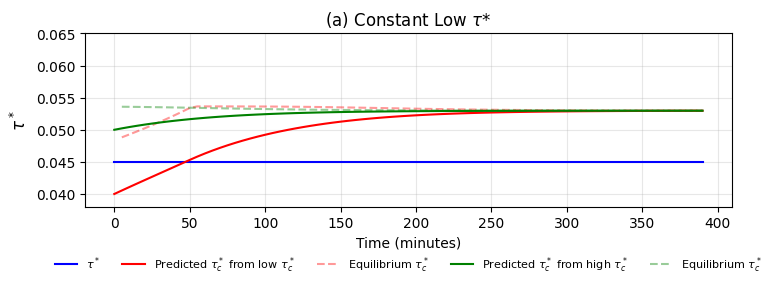

In [57]:
start = tau_star['const_low'].index[0]
tauc_min_low = 0.04

tauc_1, k_1, tau_eq_1, ratio_1 = evolve_tauc_tc(
        tau_star['const_low'],
        dt=1,
        tau_c_min=tauc_min,
        tau_c_max=tauc_max,
        event_indices=[start],
        tau_c_obs=[tauc_min_low],   # or any reasonable starting τ*c
)

start = tau_star['const_low'].index[0]
tauc_min_high = 0.05

tauc_3, k_3, tau_eq_3, ratio_3 = evolve_tauc_tc(
        tau_star['const_low'],
        dt=1,
        tau_c_min=tauc_min,
        tau_c_max=tauc_max,
        event_indices=[start],
        tau_c_obs=[tauc_min_high],   # or any reasonable starting τ*c
)

# tau_star is a pd.Series with datetime index
tau_c_pred_low_series = pd.Series(tauc_1, index=tau_star.index)
tau_c_pred_high_series = pd.Series(tauc_3, index=tau_star.index)
tau_star_series = pd.Series(tau_star['const_low'].values, index=tau_star.index)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_low_series.index, tau_c_pred_low_series.values, color='red', label=r'Predicted $\tau_c^*$ from low $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_high_series.index, tau_eq_1, color='red', alpha=0.4, linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_high_series.index, tau_c_pred_high_series.values, color='green', label=r'Predicted $\tau_c^*$ from high $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_high_series.index, tau_eq_3, color='green', alpha=0.4, linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5)

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_ylim(0.038, 0.065)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.grid(True, alpha=0.3)

ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=5, frameon=False)

plt.title(r'(a) Constant Low $\tau$*', fontsize=12)
plt.subplots_adjust(bottom=0.3)
plt.tight_layout()
plt.show()

b) - High $\tau$* (2&4)

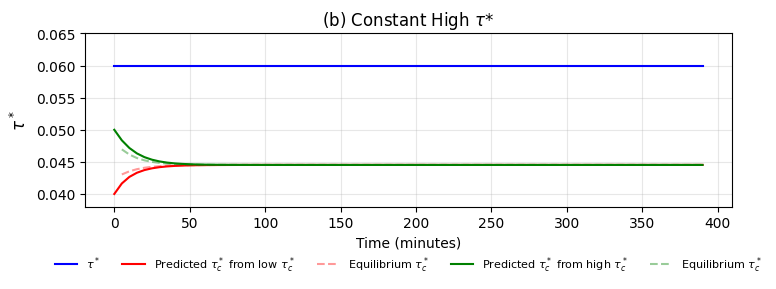

In [58]:
start = tau_star['const_high'].index[0]
tauc_min_low = 0.04

tauc_2, k_2, tau_eq_2, ratio_2 = evolve_tauc_tc(
        tau_star['const_high'],
        dt=1,
        tau_c_min=tauc_min,
        tau_c_max=tauc_max,
        event_indices=[start],
        tau_c_obs=[tauc_min_low],   # or any reasonable starting τ*c
)

start = tau_star['const_high'].index[0]
tauc_min_high = 0.05

tauc_4, k_4, tau_eq_4, ratio_4 = evolve_tauc_tc(
        tau_star['const_high'],
        dt=1,
        tau_c_min=tauc_min,
        tau_c_max=tauc_max,
        event_indices=[start],
        tau_c_obs=[tauc_min_high],   # or any reasonable starting τ*c
)

# tau_star is a pd.Series with datetime index
tau_c_pred_low_series = pd.Series(tauc_2, index=tau_star.index)
tau_c_pred_high_series = pd.Series(tauc_4, index=tau_star.index)
tau_star_series = pd.Series(tau_star['const_high'].values, index=tau_star.index)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_low_series.index, tau_c_pred_low_series.values, color='red', label=r'Predicted $\tau_c^*$ from low $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_high_series.index, tau_eq_2, color='red', alpha=0.4, linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_high_series.index, tau_c_pred_high_series.values, color='green', label=r'Predicted $\tau_c^*$ from high $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_high_series.index, tau_eq_4, color='green', alpha=0.4, linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5)

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_ylim(0.038, 0.065)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.grid(True, alpha=0.3)

ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=5, frameon=False)

plt.title(r'(b) Constant High $\tau$*', fontsize=12)
plt.subplots_adjust(bottom=0.3)
plt.tight_layout()
plt.show()

### Short Hydrographs

c) - Low $\tau$* (5&7)

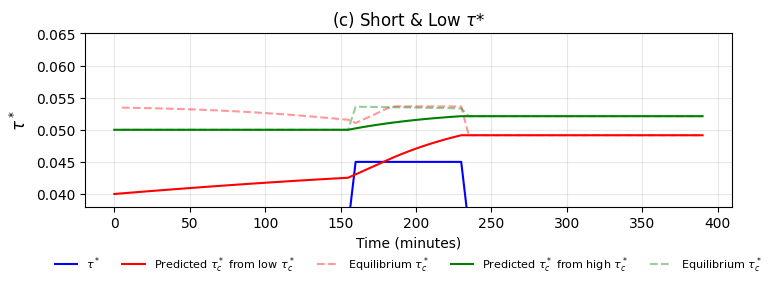

In [59]:
start = tau_star['short_low'].index[0]
tauc_min_low = 0.04

tauc_5, k_5, tau_eq_5, ratio_5 = evolve_tauc_tc(
        tau_star['short_low'],
        dt=1,
        tau_c_min=tauc_min,
        tau_c_max=tauc_max,
        event_indices=[start],
        tau_c_obs=[tauc_min_low],   # or any reasonable starting τ*c
)

tauc_min_high = 0.05

tauc_7, k_7, tau_eq_7, ratio_7 = evolve_tauc_tc(
        tau_star['short_low'],
        dt=1,
        tau_c_min=tauc_min,
        tau_c_max=tauc_max,
        event_indices=[start],
        tau_c_obs=[tauc_min_high],   # or any reasonable starting τ*c
)

# tau_star is a pd.Series with datetime index
tau_c_pred_low_series = pd.Series(tauc_5, index=tau_star.index)
tau_c_pred_high_series = pd.Series(tauc_7, index=tau_star.index)
tau_star_series = pd.Series(tau_star['short_low'].values, index=tau_star.index)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_low_series.index, tau_c_pred_low_series.values, color='red', label=r'Predicted $\tau_c^*$ from low $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_low_series.index, tau_eq_5, color='red', alpha=0.4, linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_high_series.index, tau_c_pred_high_series.values, color='green', label=r'Predicted $\tau_c^*$ from high $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_high_series.index, tau_eq_7, color='green', alpha=0.4, linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5)

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_ylim(0.038, 0.065)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.grid(True, alpha=0.3)

ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=5, frameon=False)

plt.title(r'(c) Short & Low $\tau$*', fontsize=12)
plt.subplots_adjust(bottom=0.3)
plt.tight_layout()
plt.show()

d) - High $\tau$* (6&8)

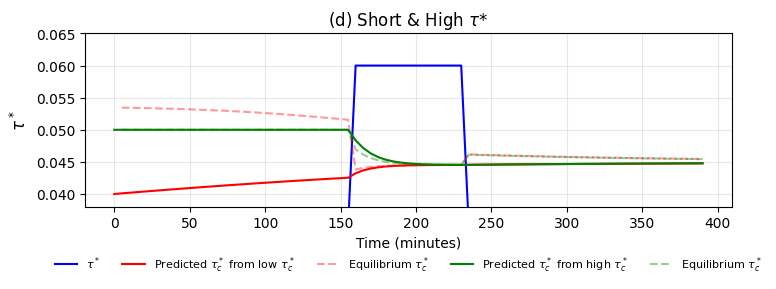

In [60]:
start = tau_star['short_high'].index[0]
tauc_min_low = 0.04

tauc_6, k_6, tau_eq_6, ratio_6 = evolve_tauc_tc(
        tau_star['short_high'],
        dt=1,
        tau_c_min=tauc_min,
        tau_c_max=tauc_max,
        event_indices=[start],
        tau_c_obs=[tauc_min_low],  
)

tauc_min_high = 0.05

tauc_8, k_8, tau_eq_8, ratio_8 = evolve_tauc_tc(
        tau_star['short_high'],
        dt=1,
        tau_c_min=tauc_min,
        tau_c_max=tauc_max,
        event_indices=[start],
        tau_c_obs=[tauc_min_high],   
)

# tau_star is a pd.Series with datetime index
tau_c_pred_low_series = pd.Series(tauc_6, index=tau_star.index)
tau_c_pred_high_series = pd.Series(tauc_8, index=tau_star.index)
tau_star_series = pd.Series(tau_star['short_high'].values, index=tau_star.index)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_low_series.index, tau_c_pred_low_series.values, color='red', label=r'Predicted $\tau_c^*$ from low $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_low_series.index, tau_eq_6, color='red', alpha=0.4, linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_high_series.index, tau_c_pred_high_series.values, color='green', label=r'Predicted $\tau_c^*$ from high $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_high_series.index, tau_eq_8, color='green', alpha=0.4, linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5)

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_ylim(0.038, 0.065)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.grid(True, alpha=0.3)

ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=5, frameon=False)

plt.title(r'(d) Short & High $\tau$*', fontsize=12)
plt.subplots_adjust(bottom=0.3)
plt.tight_layout()
plt.show()

### Long Hydrographs

d) - Low $\tau$* (9&11)

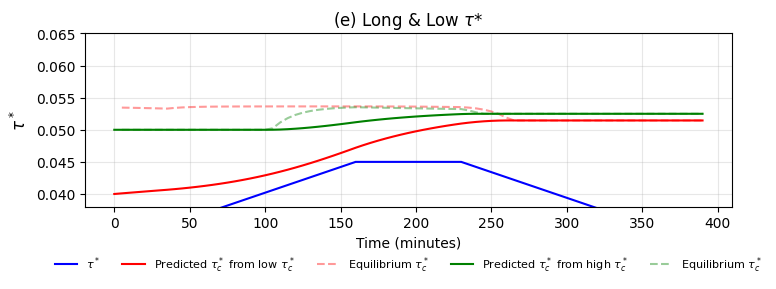

In [61]:
start = tau_star['long_low'].index[0]
tauc_min_low = 0.04

tauc_9, k_9, tau_eq_9, ratio_9 = evolve_tauc_tc(
        tau_star['long_low'],
        dt=1,
        tau_c_min=tauc_min,
        tau_c_max=tauc_max,
        event_indices=[start],
        tau_c_obs=[tauc_min_low],  
)

tauc_min_high = 0.05

tauc_11, k_11, tau_eq_11, ratio_11 = evolve_tauc_tc(
        tau_star['long_low'],
        dt=1,
        tau_c_min=tauc_min,
        tau_c_max=tauc_max,
        event_indices=[start],
        tau_c_obs=[tauc_min_high],   # or any reasonable starting τ*c
)

# tau_star is a pd.Series with datetime index
tau_c_pred_low_series = pd.Series(tauc_9, index=tau_star.index)
tau_c_pred_high_series = pd.Series(tauc_11, index=tau_star.index)
tau_star_series = pd.Series(tau_star['long_low'].values, index=tau_star.index)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_low_series.index, tau_c_pred_low_series.values, color='red', label=r'Predicted $\tau_c^*$ from low $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_low_series.index, tau_eq_9, color='red', alpha=0.4, linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_high_series.index, tau_c_pred_high_series.values, color='green', label=r'Predicted $\tau_c^*$ from high $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_high_series.index, tau_eq_11, color='green', alpha=0.4, linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5)

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_ylim(0.038, 0.065)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.grid(True, alpha=0.3)

ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=5, frameon=False)

plt.title(r'(e) Long & Low $\tau$*', fontsize=12)
plt.subplots_adjust(bottom=0.3)
plt.tight_layout()
plt.show()

f) - High $\tau$* (10&12)

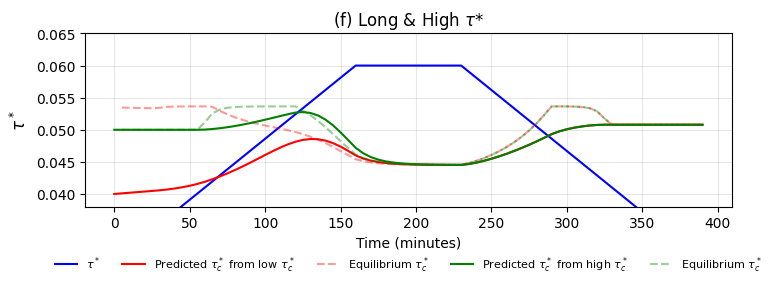

In [62]:
start = tau_star['long_high'].index[0]
tauc_min_low = 0.04

tauc_10, k_10, tau_eq_10, ratio_10 = evolve_tauc_tc(
        tau_star['long_high'],
        dt=1,
        tau_c_min=tauc_min,
        tau_c_max=tauc_max,
        event_indices=[start],
        tau_c_obs=[tauc_min_low],   
)

tauc_min_high = 0.05

tauc_12, k_12, tau_eq_12, ratio_12 = evolve_tauc_tc(
        tau_star['long_high'],
        dt=1,
        tau_c_min=tauc_min,
        tau_c_max=tauc_max,
        event_indices=[start],
        tau_c_obs=[tauc_min_high],   
)

# tau_star is a pd.Series with datetime index
tau_c_pred_low_series = pd.Series(tauc_10, index=tau_star.index)
tau_c_pred_high_series = pd.Series(tauc_12, index=tau_star.index)
tau_star_series = pd.Series(tau_star['long_high'].values, index=tau_star.index)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_low_series.index, tau_c_pred_low_series.values, color='red', label=r'Predicted $\tau_c^*$ from low $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_low_series.index, tau_eq_10, color='red', alpha=0.4, linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_high_series.index, tau_c_pred_high_series.values, color='green', label=r'Predicted $\tau_c^*$ from high $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_high_series.index, tau_eq_12, color='green', alpha=0.4, linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5)

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_ylim(0.038, 0.065)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.grid(True, alpha=0.3)

ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=5, frameon=False)

plt.title(r'(f) Long & High $\tau$*', fontsize=12)
plt.subplots_adjust(bottom=0.3)
plt.tight_layout()
plt.show()

## Subplot of all cases

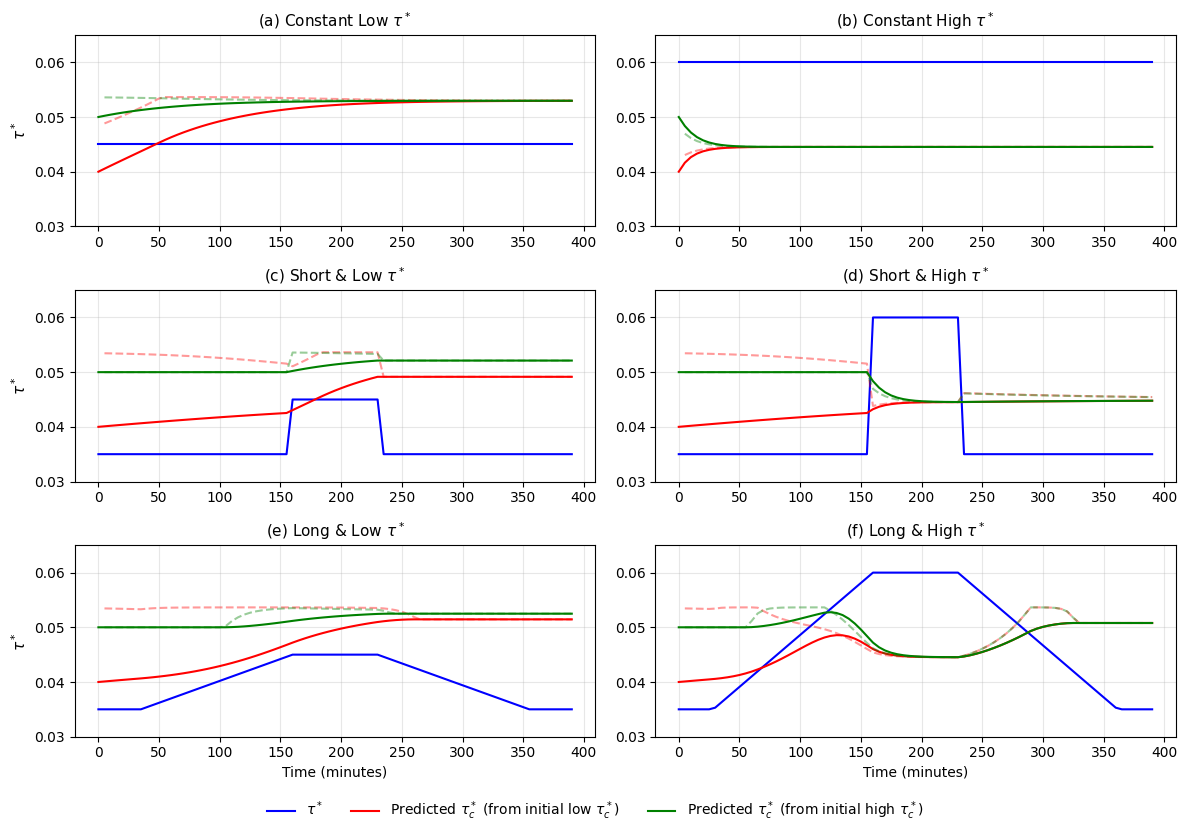

In [63]:
low_limit = 0.03
high_limit = 0.065

fig, axes = plt.subplots(3, 2, figsize=(12, 8))

# constant low
ax = axes[0, 0]
tau_star_series = pd.Series(tau_star['const_low'].values, index=tau_star.index)
tau_c_pred_low_series = pd.Series(tauc_1, index=tau_star.index)
tau_c_pred_high_series = pd.Series(tauc_3, index=tau_star.index)

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_low_series.index, tau_c_pred_low_series.values, color='red', label=r'Predicted $\tau_c^*$ (from initial low $\tau_c^*$)', linewidth=1.5)
ax.plot(tau_c_pred_low_series.index, tau_eq_1, color='red', alpha=0.4, linestyle='--', linewidth=1.5)
ax.plot(tau_c_pred_high_series.index, tau_c_pred_high_series.values, color='green', label=r'Predicted $\tau_c^*$ (from initial high $\tau_c^*$)', linewidth=1.5)
ax.plot(tau_c_pred_high_series.index, tau_eq_3, color='green', alpha=0.4, linestyle='--', linewidth=1.5)
ax.set_ylabel(r'$\tau^*$', fontsize=11)
ax.set_ylim(low_limit, high_limit)
ax.grid(True, alpha=0.3)
ax.set_title(r'(a) Constant Low $\tau^*$', fontsize=11)

# constant high
ax = axes[0, 1]
tau_star_series = pd.Series(tau_star['const_high'].values, index=tau_star.index)
tau_c_pred_low_series = pd.Series(tauc_2, index=tau_star.index)
tau_c_pred_high_series = pd.Series(tauc_4, index=tau_star.index)

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_low_series.index, tau_c_pred_low_series.values, color='red', label=r'Predicted $\tau_c^*$ (from initial low $\tau_c^*$)', linewidth=1.5)
ax.plot(tau_c_pred_low_series.index, tau_eq_2, color='red', alpha=0.4, linestyle='--', linewidth=1.5)
ax.plot(tau_c_pred_high_series.index, tau_c_pred_high_series.values, color='green', label=r'Predicted $\tau_c^*$ (from initial high $\tau_c^*$)', linewidth=1.5)
ax.plot(tau_c_pred_high_series.index, tau_eq_4, color='green', alpha=0.4, linestyle='--', linewidth=1.5)
ax.set_ylim(low_limit, high_limit)
ax.grid(True, alpha=0.3)
ax.set_title(r'(b) Constant High $\tau^*$', fontsize=11)

# low short
ax = axes[1, 0]
tau_star_series = pd.Series(tau_star['short_low'].values, index=tau_star.index)
tau_c_pred_low_series = pd.Series(tauc_5, index=tau_star.index)
tau_c_pred_high_series = pd.Series(tauc_7, index=tau_star.index)

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_low_series.index, tau_c_pred_low_series.values, color='red', label=r'Predicted $\tau_c^*$ (from initial low $\tau_c^*$)', linewidth=1.5)
ax.plot(tau_c_pred_low_series.index, tau_eq_5, color='red', alpha=0.4, linestyle='--', linewidth=1.5)
ax.plot(tau_c_pred_high_series.index, tau_c_pred_high_series.values, color='green', label=r'Predicted $\tau_c^*$ (from initial high $\tau_c^*$)', linewidth=1.5)
ax.plot(tau_c_pred_high_series.index, tau_eq_7, color='green', alpha=0.4, linestyle='--', linewidth=1.5)
ax.set_ylabel(r'$\tau^*$', fontsize=11)
ax.set_ylim(low_limit, high_limit)
ax.grid(True, alpha=0.3)
ax.set_title(r'(c) Short & Low $\tau^*$', fontsize=11)

# high short
ax = axes[1, 1]
tau_star_series = pd.Series(tau_star['short_high'].values, index=tau_star.index)
tau_c_pred_low_series = pd.Series(tauc_6, index=tau_star.index)
tau_c_pred_high_series = pd.Series(tauc_8, index=tau_star.index)

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_low_series.index, tau_c_pred_low_series.values, color='red', label=r'Predicted $\tau_c^*$ (from initial low $\tau_c^*$)', linewidth=1.5)
ax.plot(tau_c_pred_low_series.index, tau_eq_6, color='red', alpha=0.4, linestyle='--', linewidth=1.5)
ax.plot(tau_c_pred_high_series.index, tau_c_pred_high_series.values, color='green', label=r'Predicted $\tau_c^*$ (from initial high $\tau_c^*$)', linewidth=1.5)
ax.plot(tau_c_pred_high_series.index, tau_eq_8, color='green', alpha=0.4, linestyle='--', linewidth=1.5)
ax.set_ylim(low_limit, high_limit)
ax.grid(True, alpha=0.3)
ax.set_title(r'(d) Short & High $\tau^*$', fontsize=11)

# low long
ax = axes[2, 0]
tau_star_series = pd.Series(tau_star['long_low'].values, index=tau_star.index)
tau_c_pred_low_series = pd.Series(tauc_9, index=tau_star.index)
tau_c_pred_high_series = pd.Series(tauc_11, index=tau_star.index)

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_low_series.index, tau_c_pred_low_series.values, color='red', label=r'Predicted $\tau_c^*$ (from initial low $\tau_c^*$)', linewidth=1.5)
ax.plot(tau_c_pred_low_series.index, tau_eq_9, color='red', alpha=0.4, linestyle='--', linewidth=1.5)
ax.plot(tau_c_pred_high_series.index, tau_c_pred_high_series.values, color='green', label=r'Predicted $\tau_c^*$ (from initial high $\tau_c^*$)', linewidth=1.5)
ax.plot(tau_c_pred_high_series.index, tau_eq_11, color='green', alpha=0.4, linestyle='--', linewidth=1.5)
ax.set_ylabel(r'$\tau^*$', fontsize=11)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.set_ylim(low_limit, high_limit)
ax.grid(True, alpha=0.3)
ax.set_title(r'(e) Long & Low $\tau^*$', fontsize=11)

# high long
ax = axes[2, 1]
tau_star_series = pd.Series(tau_star['long_high'].values, index=tau_star.index)
tau_c_pred_low_series = pd.Series(tauc_10, index=tau_star.index)
tau_c_pred_high_series = pd.Series(tauc_12, index=tau_star.index)

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_low_series.index, tau_c_pred_low_series.values, color='red', label=r'Predicted $\tau_c^*$ (from initial low $\tau_c^*$)', linewidth=1.5)
ax.plot(tau_c_pred_low_series.index, tau_eq_10, color='red', alpha=0.4, linestyle='--', linewidth=1.5)
ax.plot(tau_c_pred_high_series.index, tau_c_pred_high_series.values, color='green', label=r'Predicted $\tau_c^*$ (from initial high $\tau_c^*$)', linewidth=1.5)
ax.plot(tau_c_pred_high_series.index, tau_eq_12, color='green', alpha=0.4, linestyle='--', linewidth=1.5)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.set_ylim(low_limit, high_limit)
ax.grid(True, alpha=0.3)
ax.set_title(r'(f) Long & High $\tau^*$', fontsize=11)

# shared legend at the bottom
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.05), frameon=False, fontsize=10)

plt.subplots_adjust(hspace=0.35, wspace=0.3, bottom=0.1)
plt.tight_layout()
plt.show()